
Oblaki, iz katerih dežuje, so podani kot četverke `(r0, c0, r1, c1)`, kjer `r0` in `r1` predstavljata vrstico, `c1` in `c2` pa stolpec. Levi gornji oblak na sliki je opisan z `(0, 1, 3, 5)`.

Slika kaže padavine v enem samem dnevu. Opišemo jih s seznamom takšnih četvork. Za primer s slike je to `[(0, 1, 3, 5), (1, 4, 2, 9), (1, 12, 2, 15), (2, 8, 9, 9), (5, 3, 9, 5), (6, 4, 8, 9), (1, 12, 2, 15), (3, 10, 7, 16), (4, 11, 6, 15), (5, 12, 10, 14), (8, 10, 9, 15)]`. Oblaki se lahko tudi prekrivajo.

Funkcije, ki jih pišete v prvih treh nalogah prejmejo argument dnevi, ki opisuje seznam padavin v več zaporednih dneh, shranjenih v seznam seznamov, kot je gornji. Za primer poglejte teste (poiščite self.oblaki).

Ozemlje je lahko zelooooo veliko, zalitih polj pa je znosno malo, recimo največ nekaj tisoč.
Pred reševanjem preberite prvi nalogi. Lahko si pripravite funkcijo, ki je izpit ne zahteva, vendar vam pride prav pri obeh nalogah.

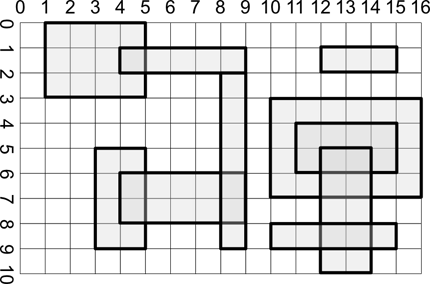

## 0. Dodatna funkcija, ki jo omenja gornje navodilo

Zgoraj preberemo, da se oblaki lahko prekrivajo. Prva naloga pravi (v odebeljeni pisavi!) **četudi isto polje zalije več oblakov, ga štejte le enkrat** in v drugi nas zanima, koliko dni je bilo polje zalito - pri čemer je spet očitno vseeno, koliko oblakov ga je zalivalo.

Smiselno je napisati funkcijo, ki bo vrnila množico polj, ki so bila zalita v posameznem dnevu (vsaj z enim oblakom). Poimenujmo jo, recimo `zalita(dan)`; prejela bo seznam oblakov posamičnega dne, se pravi seznam četverk.

In [19]:
def zaliti(dan):
    zalita = set()
    for r0, c0, r1, c1 in dan:
        for r in range(r0, r1):
            for c in range(c0, c1):
                zalita.add((r, c))
    return zalita

Krajša različica je

In [20]:
def zaliti(dan):
    return {(r, c) for r0, c0, r1, c1 in dan for r in range(r0, r1) for c in range(c0, c1)}

**Najpogostejša napaka** na izpitu je bila prav večkratno štetje istih polj.

Druga pogosta napaka je bila napačno obravnavanje mej. Namesto `range(r0, r1)` so mnogi pisali `range(r0, r1 + 1)`. V tej nalogi zgornja meja - kot je očitno iz gornjega besedila - ni vključena, torej je `+ 1` odveč. Podobna napaka so pogoji v slogu `r0 <= r <= r1` namesto `r0 <= r < r1`.

V slogu zadnje napake omenimo še, da so mnogi študenti pri drugi nalogi namesto `=> meja` pisali `> meja`. Tam naloga pač pravi "vsaj `meja` dni" in ne "več kot `meja` dni".

## 1. Poročilo

Napišite funkcijo `porocilo(dnevi, ime_datoteke)`, ki prejme seznam padavin prek nekega časovnega obdobja. Za vsak dan prešteje, koliko polj je bilo zalitih ter podatke o številu oblakov in številu zalitih polj shrani v datoteko natančno v spodnji obliki. **Četudi isto polje zalije več oblakov, ga štejte le enkrat.**

(Dan je izpisan na dve mesti, število oblakov in zalitih polj pa na 8.)

### Rešitev

Tole je naloga iz množic (v bistvu zaradi funkin iz oblikovanja nizov.

Najprej si bomo napisali funkcijo `zalita(dan)`, ki prejme seznam oblakov za posamezni dan in vrne množico koordinat zalitih polj. Pomagala nam bo namreč tudi pri naslednji nalogi.

Množico (in ne seznama) vračamo zato, da se vsako polje v njem pojavi le enkrat, tudi če ga zalije več oblakov.



In [2]:
def zaliti(dan):
    return {(r, c) for r0, c0, r1, c1 in dan for r in range(r0, r1) for c in range(c0, c1)}

Zdaj pa izpišimo poročilo.

In [3]:
def porocilo(dnevi, ime_datoteke):
    f = open(ime_datoteke, "w", encoding="utf-8")
    f.write(f"{'Oblakov':>14}{'Zalitih':>8}\n")
    f.write("-" * 22 + "\n")
    for i, dan in enumerate(dnevi, start=1):
        f.write(f"Dan {i:2}{len(dan):8}{len(zaliti(dan)):8}\n")

Datoteke se, čisto po bontonu, odpira malo drugače, vendar se v te (za Python specifične) podrobnosti nismo preveč spuščali niti na predavanjih, še manj se bomo tule.

Za nalogo je pomembna predvsem zadnja vrstica, v kateri oblikujemo niz: število dneva (`i`) izpišemo na dve mesti, število oblakov (`len(dan)`) in število zalitih polj (`len(zaliti(dan))`) na osem. Potem tudi ne pozabimo iti v novo vrstico, z `\n`.

Eno vrstico prej imamo zanimivo zanko: ne le `for dan in dnevi`, temveč `for i, dan in enumerate(dnevi, start=1)`, saj potrebujemo tudi zaporedno številko dneva (ker jo moramo pač izpisati), `start=1` pa je potreben zato, da `enumerate` šteje od `1` in ne od `0`. Če za ta argument ne vemo, pač pišemo `for i, dan in enumerate(dnevi)`, potem pa namesto `i` izpisujemo `i + 1`.

Če gremo še dve vrstici višje: tam izpišemo prvo vrstico, ("Oblakov" in "Zalitih") na ustrezno število mest, potem pa še primerno število minusov.

## 2. Zalita

Napišite funkcijo `zalita(dnevi, meja)`, ki prejme padavine prek več dni in vrne množico koordinat vseh polj, na katerih je deževalo na vsaj `meja` dni.

Klic `zalita(oblaki, 15)` (na oblakih iz testov) vrne `{(13, 11), (13, 12), (13, 13)}`, ker so to edina polja, na katerih je deževalo vsaj v 15 dneh.

### Rešitev

Tole je pa naloga iz slovarjev. Ključi bodo polja, vrednosti število dni, ko je to polje prejelo dež. Gremo čez vse dneve, za vsakega pokličemo funkcijo `zaliti`, ki smo si jo pripravili prej, in vsem zalitim poljem povečamo števec. Nato pripravimo množico, ki jo bomo vrnili kot rezultat. Gremo čez slovar, poiščemo vse elemente, pri katerih je vrednost (število dni) enaka ali večja meji, ter pripadajoče ključe zlagamo v množico, ki jo na koncu vrnemo.

In [4]:
def zalita(dnevi, meja):
    zalitost = {}
    for dan in dnevi:
        for polje in zaliti(dan):
            if polje not in zalitost:
                zalitost[polje] = 0
            zalitost[polje] += 1

    zalita_polja = set()
    for polje, stevilo in zalitost.items():
        if stevilo >= meja:
            zalita_polja.add(polje)
    return zalita_polja

Delo si olajšamo, če namesto običajnega slovarja vzamemo `defaultdict`, množico pa kar izpeljemo iz slovarja.

In [5]:
from collections import defaultdict

def zalita(dnevi, meja):
    zalitost = defaultdict(int)
    for dan in dnevi:
        for polje in zaliti(dan):
            zalitost[polje] += 1

    return {polje for polje, stevilo in zalitost.items() if stevilo >= meja}

## 3. Dolžina suše

Napišite funkcijo `dolzina_suse(dnevi, vrstica, stolpec)`, ki za podano polje `(vrstica, stolpec)` vrne najdaljše število zaporednih dni brez dežja. (Vrstica in stolpec sta podana tako, da ima gornje levo polje koordinate 0, 0).

Za primere iz testov je na polju `(5, 15)` deževalo na dnevih označenih z X v zaporedju: ..X..XXX...XX.X.....X. Najdaljše obdobje suše je trajalo 5 dni (saj imamo pet zaporednih pik).

### Rešitev

(Načelno) ima vsak izpit nalogo, ki pokaže, da študent zna napisati malenkost bolj zavozlano kombinacijo for in if. Na tem izpitu je to ta naloga.

Najprej napišimo (zelo) nepythonovsko rešitev.

In [6]:
def dolzina_suse(dnevi, y, x):
    najdaljsa_susa = 0
    trenutna_susa = 0
    for dan in dnevi:    
        zalito = False
        for y0, x0, y1, x1 in dan:
            if y0 <= y < y1 and x0 <= x < x1:
                zalito = True
                break
        if zalito:
            trenutna_susa = 0
        else:
            trenutna_susa += 1
            if trenutna_susa > najdaljsa_susa:
                najdaljsa_susa = trenutna_susa
    return najdaljsa_susa

Kaj bomo shranjevali v `trenutna_susa` in `najdaljsa_susa`, je očitno.

Gremo čez dneve. V notranji zanki poskušamo najti oblak, ki zalije podano polje. Če ga najdemo, postavimo `zalito` na `True` (in prekinemo zanko z `break`, saj je nima smisla nadaljevati), sicer ostane `False`. Ko je ta zanka končana, preverimo, ali je polje zalito. Če je tako, prekinemo trenutno sušo (postavimo jo na 0). Sicer povečamo trajanje trenutne suše za 1 in preverimo, ali smo s tem presegli najdaljšo sušo.

Trik, ki ga tule ponudi Python, je `else` po `for`-u. Če najdemo oblak, ki zalije tenutno polje, končamo sušo in prekinemo zanko. Če se zanka ne prekine, pa polje ni bilo zalito, torej podaljšamo trajanje suše.

In [7]:
def dolzina_suse(dnevi, y, x):
    suse = 0
    trenutna_susa = 0
    for dan in dnevi:
        for y0, x0, y1, x1 in dan:
            if y0 <= y < y1 and x0 <= x < x1:
                trenutna_susa = 0
                break
        else:
            trenutna_susa += 1
            suse = max(suse, trenutna_susa)
    return suse

Mimogrede smo se s funkcijo `max` znebili še enega `if`-a.

Še preprosteje je, če poznamo generatorje in znamo uporabiti funkcijo `any`.

In [8]:
def dolzina_suse(dnevi, y, x):
    suse = 0
    trenutna_susa = 0
    for dan in dnevi:
        if any(x0 <= x < x1 and y0 <= y < y1 for y0, x0, y1, x1 in dan):
            trenutna_susa = 0
        else:
            trenutna_susa += 1
            suse = max(suse, trenutna_susa)
    return suse

Eden od študentov je reševal nalogo tako, da je shranil indekse vseh deževnih dni, potem pa poiskal največjo razliko med zaporednima indeksoma.

In [15]:
# Tole ne deluje čisto pravilno
def dolzina_suse(dnevi, vrstica, stolpec):
    niz = []
    for i, dan in enumerate(dnevi):
        for r0, c0, r1, c1 in dan:
            if c0 <= stolpec < c1 and r0 <= vrstica < r1:
                niz.append(i)
                break

    najvecja_razlika = 0
    for dan1, dan2 in zip(niz, niz[1:]):
        razlika = dan2 - dan1
        if razlika > najvecja_razlika:
            najvecja_razlika = razlika

    return najvecja_razlika

Funkcija ni prostorsko učinkovita, saj sestavlja seznam, ki v resnici ni potreben. Je pa po svoje elegantna, izvirna. Všeč mi je.

Žal ima dve manjši napaki.

Prva je tale: če dežuje na 5 in 9 dan, vmes ni 9 - 5 = 4 sušnih dni, temveč le trije (namreč 6, 7, 8). Namesto `dan2 - dan1` bi moralo biti `dan2 - dan1 - 1`.

Drugi problem je, da funkcija opazuje razlike med zaporednimi dnevi, zato ne bo opazila suš, ki se pojavijo na začetku in na koncu zaporedja. To uredimo preprosto tako, da si izmislimo, da je deževalo še na en dan prej začetkom (dan z indeksom `-1`) in na dan po koncu (dan z indeksom `len(dnevi)`). `niz = []` torej zamenjamo z `niz = [-1]` in za prvo zanko dodamo `niz.append(len(dnevi))`.

In [16]:
def dolzina_suse(dnevi, vrstica, stolpec):
    niz = [-1]
    for i, dan in enumerate(dnevi):
        for r0, c0, r1, c1 in dan:
            if c0 <= stolpec < c1 and r0 <= vrstica < r1:
                niz.append(i)
                break
    niz.append(len(dnevi))

    najvecja_razlika = 0
    for dan1, dan2 in zip(niz, niz[1:]):
        razlika = dan2 - dan1 - 1
        if razlika > najvecja_razlika:
            najvecja_razlika = razlika

    return najvecja_razlika

To se da, če bi koga zanimalo, lepo spraviti v en sam izraz, katerega lepota je tudi, da v resnici ne sestavlja seznama indeksov in je zato prostorsko učinkovitejši. Naj razume, kdor hoče. (Ne boste pa me slišali trditi, da je v tej, spodnji obliki, to primer lepega programiranja, vsaj ne v Pythonu.)

In [17]:
from itertools import pairwise, chain

def dolzina_suse(dnevi, vrstica, stolpec):
    return max(dan2 - dan1 - 1
               for dan1, dan2 in pairwise(chain(
                   (-1, ),
                   (i for i, dan in enumerate(dnevi)
                    if any(r0 <= vrstica < r1 and c0 <= stolpec < c1 for r0, c0, r1, c1 in dan)),
                     (len(dnevi), )
               )))

## 4. Angelček

Angelček brez kril hodi po oblakih. Če začne na, na primer, `(2, 8, 9, 9)`, lahko nadaljuje pot na `(1, 4, 2, 9)` in od ondod na `(0, 1, 3, 5)`. Lahko pa gre tudi na `(6, 4, 8, 9)` in na `(5, 3, 9, 5)`. Ne more pa na `(3, 10, 7, 16)`.

Napišite funkcijo `premiki(oblak, oblaki, prepovedani)`, ki prejme nek oblak (četverko), padavine v posamičnem dnevu (seznam četverk) in seznam prepovedanih oblakov, kamor ne bo (več?) šel. Funkcija mora vrniti množico vseh oblakov, ki jih lahko angelček doseže s podanega oblaka.

Testi bodo kot "prepovedane" oblake podali prazno množico. Ta argument lahko funkcija uporabi zato, da vanj dodaja obiskane oblake in kasneje prepreči, da bi se angelček "zaciklal", tako da bi obiskal oblak, na katerem je že bil.

Za pomoč je že podana funkcija `oblaka_se_dotikata(oblak1, oblak2)`, ki vrne `True`, če se oblaka dotikata oz. sekata.

In [9]:
def oblaka_se_dotikata(oblak1, oblak2):
    x0, y0, x1, y1 = oblak1
    x2, y2, x3, y3 = oblak2
    return max(x0, x2) <= min(x1, x3) and max(y0, y2) <= min(y1, y3)

### Rešitev

Tole je naloga iz rekurzije.

In [10]:
def premiki(oblak, oblaki, prepovedani):
    dostopni = {oblak}
    for oblak2 in oblaki:
        if oblak2 not in prepovedani and oblaka_se_dotikata(oblak, oblak2):
            dostopni |= premiki(oblak2, oblaki, prepovedani | {oblak2})
    return dostopni

Dostopen je, očitno, oblak, na katerem se angelček nahaja v začetku. Nato gremo čez vse oblake. Če določen oblak ni prepovedan in se dotika trenutnega, dodamo v množico `dostopni` še vse oblake, ki so dostopni iz tega oblaka. Pri tem trenutni oblak dodamo med prepovedane, da se angelček ne bi slučajno vrnil nanj, saj bi se funkcija v tem primeru zaciklala.

Ljubitelji jedrnatih rekurzivnih funkcij, ki poznajo generatorje in čudne načine podajanja argumentov, pa lahko napišejo tudi

In [13]:
def premiki(oblak, oblaki, prepovedani):
    return {oblak}.union(*(premiki(oblak2, oblaki, prepovedani | {oblak2})
       for oblak2 in oblaki if oblaka_se_dotikata(oblak, oblak2) and oblak2 not in prepovedani))

Eden od študentov je to rešil na nepričakovan, a na (zelo pogojno!) pravilen način.

In [14]:
def premiki(oblak, oblaki, prepovedani):
    prepovedani.add(oblak)
    for oblak1 in oblaki:
        if oblaka_se_dotikata(oblak2, oblak) and oblak2 not in prepovedani:
            premiki(oblak2, oblaki, prepovedani)
    return prepovedani

Ta funkcija je v bistvu enaka prvi, le da ne sestavlja množice dostopnih oblakov; ti se tako ali tako nabirajo v množici `prepovedani`. Rezultata rekurzivnega klica (`premiki(oblak2, oblaki, prepovedani)`) nikjer ne uporabimo, pač pa na koncu vrnemo `prepovedani`.

To sicer da pravilen rezultat, vendar temelji na tem, da **spreminja** podano množico `prepovedani` - vsi rekurzivni klici namreč dodajajo v eno in isto množico (če poskusimo to spremeniti, bo funkcija nehala delovati), zato bo zadnji `return` vrnil pravilno vrednost. Moja funkcija (ona, prva, zgoraj) pa ne dodaja v `prepovedani` (nikjer ni nobenega `prepovedani.add`!), temveč sestavi unijo doslej prepovedanih in novega oblaka (`prepovedani | {oblak2}`).

Ta, študentska rešitev, bo vseeno delovala, če bo ta, ki kliče, funkcijo vedno poklical z novo prazno množico, `set()`.

## 5. Kmetija

Napišite razred `Kmetija`.
-	Konstruktor prejme velikost kmetije (število vrstic in stolpcev) ter četvorko s koordinatami oblaka.
-	Metoda `premik_oblaka(smer)` prejme argument smer, `"<"`, `">"`, `"^"` ali `"v"`, ter premakne oblak za eno polje v podani smeri.
-	Metoda `odpri_vodo()` izpusti eno porcijo dežja iz oblaka na polja pod njim.
-	Metoda `padavine(vrstica, stolpec)` vrne število porcij dežja, ki jih je prejelo podano polje.

### Rešitev

Tole pa je očitno naloga iz objektnega programiranja. Pri teh nalogah si je potrebno predvsem zamisliti, kakšne podatke mora hraniti objekt. Tule bo to pozicija oblaka ter zalitost polj.

In [18]:
class Kmetija:
    def __init__(self, vrstic, stolpcev, oblak):
        self.oblak = oblak
        self.zalitost = [[0] * stolpcev for _ in range(vrstic)]

    def premik_oblaka(self, smer):
        r0, c0, r1, c1 = self.oblak
        dr, dc = {"v": (1, 0), "^": (-1, 0), "<": (0, -1), ">": (0, 1)}[smer]
        self.oblak = (r0 + dr, c0 + dc, r1 + dr, c1 + dc)

    def odpri_vodo(self):
        r0, c0, r1, c1 = self.oblak
        for r in range(r0, r1):
            for c in range(c0, c1):
                if 0 <= r < len(self.zalitost) and 0 <= c < len(self.zalitost[0]):
                    self.zalitost[r][c] += 1

    def padavine(self, vrstica, stolpec):
        return self.zalitost[vrstica][stolpec]


Konstruktor je očiten: v `self.oblak` shranimo koordinate oblaka, v `self.zalitost` pa seznam seznamov z zalitostmi. Tu je pomembno, da pišemo `self.zalitost = [[0] * stolpcev for _ in range(vrstic)]` ali, če nam generatorji ne ležijo

```
self.zalitost = []
for _ in range(vrstic):
    self.zalitost.append([0] * stolpcev)
```

Če bi pisali `self.zalitost = [[0] * stolpcev] * vrstic`, bi dobili seznam, ki `vrstico`-krat vsebuje **isti** seznam ničel.

Koordinate oblaka smo shranili v terki. Lahko bi jo tudi v posamičnih spremenljivkah,

```
    self.r0, self.c0, self.r1, self.c1 = oblak
```

S tem bi si prihranili razpakiranje v funkcijah `premik_oblaka` in `odpri_vodo`, vendar hkrati nakopali kupe `self`-ov. Naj bo, kot je.

`premik_oblaka` razpakira oblak v koordinate, ugotovi, koliko je potrebno spremeniti `c` in `r` ter ga spremeni. Če smo spretni, uporabimo slovar, sicer gre tudi z `if`-i:

```
    if premik == "<":
        self.oblak = (r0, c0 - 1, r1, c1 - 1)
    if premik == ">":
        ... in tako naprej
```

Pri odpiranju vode pazimo, da je oblak morda delno (ali povsem) izven kmetije; `if` bo poskrbel, da padavin s tega dela oblaka ne zapisujemo, saj teh polj ni v `self.zalitost`; rezultat bi bil `Index out of range`.

`padavine` le vrne ustrezni element seznama `self.zalitost`.